# Retail Customer & Category Analysis — SQL + Python
**Author:** Enoch Effah  
**Dataset:** Superstore Orders (MySQL — superstore_db)  
**Tools:** MySQL, Python, pandas, matplotlib, seaborn  
**Date:** May 2026

## Project Overview
This notebook connects directly to a MySQL database to analyze customer 
profitability, category performance, and regional trends. SQL handles 
the data aggregation and filtering — Python handles the visualization 
and storytelling.

## Business Questions
1. Who are our most and least profitable customers?
2. Which product categories and sub-categories generate the most losses?
3. Which region and category combination is most and least profitable?

## Setup Note
Database credentials are stored securely in a `.env` file and never 
committed to GitHub. The `.env` file is excluded via `.gitignore`.

In [1]:
from dotenv import load_dotenv
import os

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


load_dotenv()

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.environ.get("MYSQL_PASSWORD", ""),
    database="superstore_db"
)

print("Connection successful")

Connection successful


## Customer Profitability Analysis

**Business Question:** Who are our most and least profitable customers, 
and is high spending always correlated with high profit?

**Method:** We query customer sales, profit, profit margin, and 
average discount directly from MySQL. We filter for customers with 
total sales above $5,000 to remove low-volume customers whose margins 
may be misleading.

In [21]:
# Customer profitability

query = """ 
    SELECT 
        customer_name, 
        ROUND(SUM(sales), 2) AS total_sales, 
        ROUND(SUM(profit), 2) AS total_profit, 
        ROUND((SUM(profit) / SUM(sales) * 100), 2) AS profit_margin,
        ROUND(AVG(discount), 2) AS average_discount
    FROM orders
    GROUP BY customer_name
    HAVING total_sales > 5000
    ORDER BY profit_margin ASC;

"""

df_customers = pd.read_sql(query, conn)
print(df_customers.shape)
df_customers.head(10)

(115, 5)


C:\Users\enoch\AppData\Local\Temp\ipykernel_59844\2589963626.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql(query, conn)


,customer_name,total_sales,total_profit,profit_margin,average_discount
0,Cindy Stewart,5690.06,-6626.39,-116.46,0.20
1,Grant Thornton,9351.21,-4108.66,-43.94,0.25
2,Christine Phan,5888.28,-1850.30,-31.42,0.21
3,Sean Braxton,8057.89,-2082.75,-25.85,0.24
4,Tom Prescott,5329.00,-1087.39,-20.41,0.46
5,Natalie Fritzler,8322.83,-1695.97,-20.38,0.25
6,Becky Martin,11609.90,-1711.43,-14.74,0.19
7,Victoria Wilson,6112.70,-882.40,-14.44,0.16
8,Zuschuss Carroll,8021.14,-1028.34,-12.82,0.24
9,Joseph Airdo,6475.47,-825.06,-12.74,0.21


## Customer Profit Margin Analysis

**Key Insights:** This chart shows the 20 worst performing customers 
by profit margin, ranging from Grant Thornton at -43.94% to Mick 
Hernandez who barely breaks even at +3.11%. Note: Cindy Stewart was 
excluded as an extreme outlier at -116% profit margin and warrants 
separate investigation.

Grant Thornton is particularly alarming — the company generates $9,351 
in sales but loses $4,108, driven by a 25% average discount on 
high-value Machines purchases. Most problematic customers carry average 
discounts between 0.20 and 0.25.

**Recommendation:** Cap customer-level discounts at 20% maximum. 
Customers receiving discounts above this threshold consistently generate 
losses regardless of sales volume.

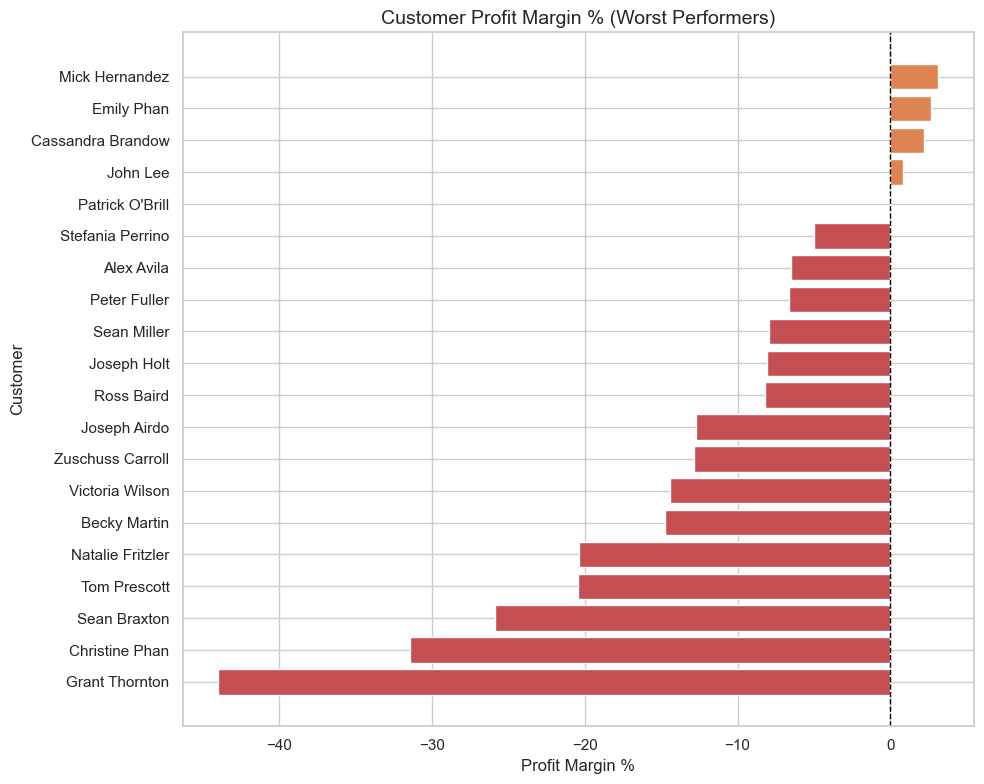

In [22]:
df_worst = df_customers[
    (df_customers["profit_margin"] < 10) & (df_customers["profit_margin"] > -50)
].head(20)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#C44E52" if x < 0 else "#DD8452"
          for x in df_worst["profit_margin"]]

bars = ax.barh(df_worst["customer_name"], df_worst["profit_margin"], color = colors)

ax.axvline(x=0, color="black", linestyle="--", linewidth = 1)
ax.set_title("Customer Profit Margin % (Worst Performers)", fontsize=14)
ax.set_xlabel("Profit Margin %")
ax.set_ylabel("Customer")

plt.tight_layout()
plt.show()